# Notebook 4 — Architecture cVAE Quality-Aware

**Objectif :** Brancher le score de qualité $c \in [0,1]$ (Notebook 3) sur l'architecture MedVAE de Stanford,  
en créant un **Variational Autoencoder Conditionnel (cVAE) quality-aware**.

**Principe du conditionnement :**

$$\text{Encodeur} : x_{\text{cond}} = \text{cat}\bigl([x,\; c_{\text{spatial}}]\bigr) \xrightarrow{\text{Encoder}} \mu, \sigma \xrightarrow{\text{reparam.}} z$$

$$\text{Décodeur} : z_{\text{cond}} = \text{cat}\bigl([\text{post\_quant\_conv}(z),\; c_{\text{spatial}}]\bigr) \xrightarrow{\text{Decoder}} \hat{x}$$

où $c_{\text{spatial}} \in \mathbb{R}^{B \times 1 \times H \times W}$ est le score de qualité broadcast spatialement.

**Pourquoi injecter aux deux extrémités ?**
- **Encodeur** : force la représentation latente à être consciente de la qualité de l'image compressée.
- **Décodeur** : permet au réseau de *choisir* le niveau de détail à reconstruire selon la qualité déclarée.

**Stratégie d'initialisation :** les nouveaux filtres sont initialisés à zéro → au départ, $c$ n'a aucun effet (stabilité du fine-tuning).

## 0. Configuration

In [13]:
from pathlib import Path

# --- Chemins ---
NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent                                      # projet_med_vae/
JEPA_ROOT     = PROJECT_ROOT.parent / "projet_IM06" / "jepa-adaptation"  # IM_06/projet_IM06/jepa-adaptation/
OUTPUT_DIR    = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

LABELS_CSV    = OUTPUT_DIR / "labels_quality.csv"  # sortie Notebook 3
PHASE1_CKPT   = None  # ex: JEPA_ROOT / "outputs/pretraining/phase1/best.pt"
CVAE_CKPT_OUT = OUTPUT_DIR / "quality_aware_vae.pt"

# --- Config modèle (doit correspondre à pretraining.yaml) ---
DDCONFIG = {
    "double_z":        True,
    "z_channels":      4,
    "resolution":      64,
    "in_channels":     1,
    "out_ch":          1,
    "ch":              128,
    "ch_mult":         [1, 2, 4],
    "num_res_blocks":  2,
    "attn_resolutions":[],
    "dropout":         0.0,
}
EMBED_DIM = 4

# --- Config entraînement (démonstration) ---
N_WARMUP_STEPS = 50      # augmenter pour un vrai entraînement (ex: 50 000)
LR             = 4.5e-6
BATCH_SIZE     = 4
KL_WEIGHT      = 1e-6

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"JEPA_ROOT    : {JEPA_ROOT}")
print(f"Labels CSV   : {LABELS_CSV}")

PROJECT_ROOT : C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae
JEPA_ROOT    : C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_IM06\jepa-adaptation
Labels CSV   : C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae\code_tests\outputs\labels_quality.csv


## 1. Imports et setup sys.path

In [14]:
import sys
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
torch.manual_seed(42)

# Rendre le code JEPA importable depuis ce notebook
jepa_str = str(JEPA_ROOT)
if jepa_str not in sys.path:
    sys.path.insert(0, jepa_str)

from models import AutoencoderKL2D
from models.medvae_jepa.modules.distributions import DiagonalGaussianDistribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cpu
PyTorch : 2.10.0+cpu


## 2. Chargement de labels_quality.csv

In [15]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Labels chargés : {len(df_labels)} images")
print(df_labels[["image_id", "quality_score", "quality_label"]].describe())
df_labels.head(3)

Labels chargés : 1200 images
          image_id  quality_score
count  1200.000000    1200.000000
mean    433.833333       0.466444
std     303.807595       0.176758
min       1.000000       0.166278
25%     150.750000       0.302318
50%     400.500000       0.449165
75%     700.250000       0.604933
max    1000.000000       0.876379


,image_id,path,quality_score,quality_label,score_weighted,score_pca,score_resnet,score_hybrid
0,1,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.481270,medium,0.413409,0.341742,0.688658,0.481270
1,10,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.485919,medium,0.368684,0.211145,0.877929,0.485919
2,100,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.566607,good,0.453849,0.387754,0.858219,0.566607


## 3. Dataset : QualityAwareArcadeDataset

Modification minimale du DataLoader existant : on retourne `(image, quality_score)` au lieu de `(image, mask)`.

In [16]:
class QualityAwareArcadeDataset(Dataset):
    """
    Charge les images ARCADE et leur score de qualité associé.
    
    Retourne : (image: FloatTensor (1,H,W), quality_score: FloatTensor scalar)
    """
    def __init__(self, df: pd.DataFrame, img_size: int = 64):
        # Ne garder que les lignes avec un fichier image accessible
        self.records = df.dropna(subset=["path", "quality_score"]).reset_index(drop=True)
        self.img_size = img_size

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        row = self.records.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).unsqueeze(0)
            # Recadrage [-1, 1] (convention MedVAE)
            img = img * 2.0 - 1.0
        except Exception:
            img = torch.zeros(1, self.img_size, self.img_size)

        c = torch.tensor(float(row["quality_score"]), dtype=torch.float32)
        return img, c


dataset = QualityAwareArcadeDataset(df_labels, img_size=DDCONFIG["resolution"])
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

imgs_demo, scores_demo = next(iter(loader))
print(f"Batch images : {imgs_demo.shape}   scores : {scores_demo.shape}")
print(f"Scores du batch : {scores_demo.tolist()}")

Batch images : torch.Size([4, 1, 64, 64])   scores : torch.Size([4])
Scores du batch : [0.3066878020763397, 0.2731989622116089, 0.7314981818199158, 0.6208965182304382]


## 4. Architecture : QualityAwareAutoencoderKL

### 4a. Principe du patching

L'architecture de base (`AutoencoderKL2D`) possède deux portes d'entrée :

| Couche | Forme avant | Forme après patching |
|---|---|---|
| `encoder.conv_in` | `Conv2d(1, 128, 3)` | `Conv2d(2, 128, 3)` |
| `decoder.conv_in` | `Conv2d(4, 512, 3)` | `Conv2d(5, 512, 3)` |

On remplace ces deux couches. Tous les autres poids restent inchangés.

In [17]:
def _patch_conv_in(old_conv: nn.Conv2d, extra_in: int = 1) -> nn.Conv2d:
    """
    Remplace une Conv2d par une version avec `extra_in` canaux d'entrée supplémentaires.
    Les poids existants sont copiés. Le nouveau canal est initialisé à zéro
    (absence d'effet au démarrage → stabilité du fine-tuning).
    """
    new_conv = nn.Conv2d(
        old_conv.in_channels + extra_in,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )
    with torch.no_grad():
        new_conv.weight[:, :old_conv.in_channels].copy_(old_conv.weight)
        new_conv.weight[:, old_conv.in_channels:].zero_()   # ← clé : zero-init
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)
    return new_conv


print("Fonction _patch_conv_in définie.")

Fonction _patch_conv_in définie.


### 4b. Classe QualityAwareAutoencoderKL

In [18]:
class QualityAwareAutoencoderKL(nn.Module):
    """
    cVAE conditionné sur un score de qualité scalaire c ∈ [0, 1].

    c est injecté comme canal spatial constant à deux endroits :
    1. Entrée de l'encodeur : cat([x, c_map], dim=1)
    2. Entrée du décodeur   : cat([post_quant_conv(z), c_map], dim=1)

    Tous les poids du modèle de base sont préservés.
    Les nouveaux filtres sont zero-initialisés.
    """

    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae
        self._patch_encoder()
        self._patch_decoder()

    def _patch_encoder(self):
        enc = self.ae.encoder
        enc.conv_in = _patch_conv_in(enc.conv_in, extra_in=1)

    def _patch_decoder(self):
        dec = self.ae.decoder
        dec.conv_in = _patch_conv_in(dec.conv_in, extra_in=1)

    @staticmethod
    def _inject_condition(x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """Broadcast c (B,) en carte spatiale (B, 1, H, W) et concatène à x."""
        B, _, H, W = x.shape
        c_map = c.float().view(B, 1, 1, 1).expand(B, 1, H, W)
        return torch.cat([x, c_map], dim=1)

    def encode(self, x: torch.Tensor, c: torch.Tensor) -> DiagonalGaussianDistribution:
        x_cond  = self._inject_condition(x, c)          # (B, 2, H, W)
        h       = self.ae.encoder(x_cond)               # encodeur reçoit 2 canaux
        moments = self.ae.quant_conv(h)
        return DiagonalGaussianDistribution(moments)

    def decode(self, z: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        z_post  = self.ae.post_quant_conv(z)            # (B, z_channels, h, w)
        z_cond  = self._inject_condition(z_post, c)     # (B, z_channels+1, h, w)
        return self.ae.decoder(z_cond)                  # décodeur reçoit z_channels+1 canaux

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        sample_posterior: bool = True,
    ):
        posterior = self.encode(x, c)
        z = posterior.sample() if sample_posterior else posterior.mode()
        dec = self.decode(z, c)

        latent = None
        if self.ae.apply_channel_ds:
            latent = self.ae.channel_proj(self.ae.channel_ds(z) + z)

        return dec, posterior, latent

    def get_last_layer(self):
        return self.ae.get_last_layer()

    def param_count(self) -> dict:
        total  = sum(p.numel() for p in self.parameters())
        new    = (self.ae.encoder.conv_in.weight[:, -1].numel() +
                  self.ae.decoder.conv_in.weight[:, -1].numel())
        return {"total": total, "new_params": new, "ratio_%": 100 * new / total}


print("QualityAwareAutoencoderKL définie.")

QualityAwareAutoencoderKL définie.


## 5. Instanciation et vérification de l'architecture

In [19]:
# Modèle de base
base_ae = AutoencoderKL2D(
    ddconfig         = DDCONFIG,
    embed_dim        = EMBED_DIM,
    ckpt_path        = PHASE1_CKPT,
    apply_channel_ds = True,
)

# Modèle conditionné
cvae = QualityAwareAutoencoderKL(base_ae).to(DEVICE)

# Résumé
pc = cvae.param_count()
print(f"\nParamètres totaux    : {pc['total']:,}")
print(f"Paramètres nouveaux  : {pc['new_params']:,}  ({pc['ratio_%']:.4f}% du total)")
print(f"\nencoder.conv_in : {cvae.ae.encoder.conv_in}")
print(f"decoder.conv_in : {cvae.ae.decoder.conv_in}")

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 512 in_channels

Paramètres totaux    : 55,364,605
Paramètres nouveaux  : 5,760  (0.0104% du total)

encoder.conv_in : Conv2d(2, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
decoder.conv_in : Conv2d(5, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [20]:
# --- Forward pass de vérification ---
x_test = imgs_demo.to(DEVICE)
c_test = scores_demo.to(DEVICE)

with torch.no_grad():
    rec, posterior, latent = cvae(x_test, c_test, sample_posterior=False)

print("Forward pass OK :")
print(f"  Entrée      : {x_test.shape}")
print(f"  Scores c    : {c_test.tolist()}")
print(f"  Reconstruction : {rec.shape}")
print(f"  Latent z    : {posterior.mean.shape}")
print(f"  MSE(x, rec) : {F.mse_loss(x_test, rec).item():.6f}")

Forward pass OK :
  Entrée      : torch.Size([4, 1, 64, 64])
  Scores c    : [0.3066878020763397, 0.2731989622116089, 0.7314981818199158, 0.6208965182304382]
  Reconstruction : torch.Size([4, 1, 64, 64])
  Latent z    : torch.Size([4, 4, 16, 16])
  MSE(x, rec) : 0.263457


In [21]:
# --- Vérification du flux de gradient ---
cvae.train()
x_grad = imgs_demo[:1].to(DEVICE).requires_grad_(False)
c_grad = scores_demo[:1].to(DEVICE).requires_grad_(True)   # on veut grad par rapport à c

rec_grad, post_grad, _ = cvae(x_grad, c_grad, sample_posterior=False)
loss_grad = F.mse_loss(rec_grad, x_grad)
loss_grad.backward()

print("Flux de gradient :")
print(f"  ∂loss/∂c         : {c_grad.grad.item():.6f}  (non-nul → c influence la loss)")
print(f"  encoder.conv_in grad : "
      f"{cvae.ae.encoder.conv_in.weight.grad[:,:,1,1].abs().mean().item():.6f}")
print(f"  decoder.conv_in grad : "
      f"{cvae.ae.decoder.conv_in.weight.grad[:,:,1,1].abs().mean().item():.6f}")
cvae.zero_grad()

Flux de gradient :
  ∂loss/∂c         : 0.000000  (non-nul → c influence la loss)
  encoder.conv_in grad : 0.003657
  decoder.conv_in grad : 0.002054


## 6. Visualisation du schéma architectural

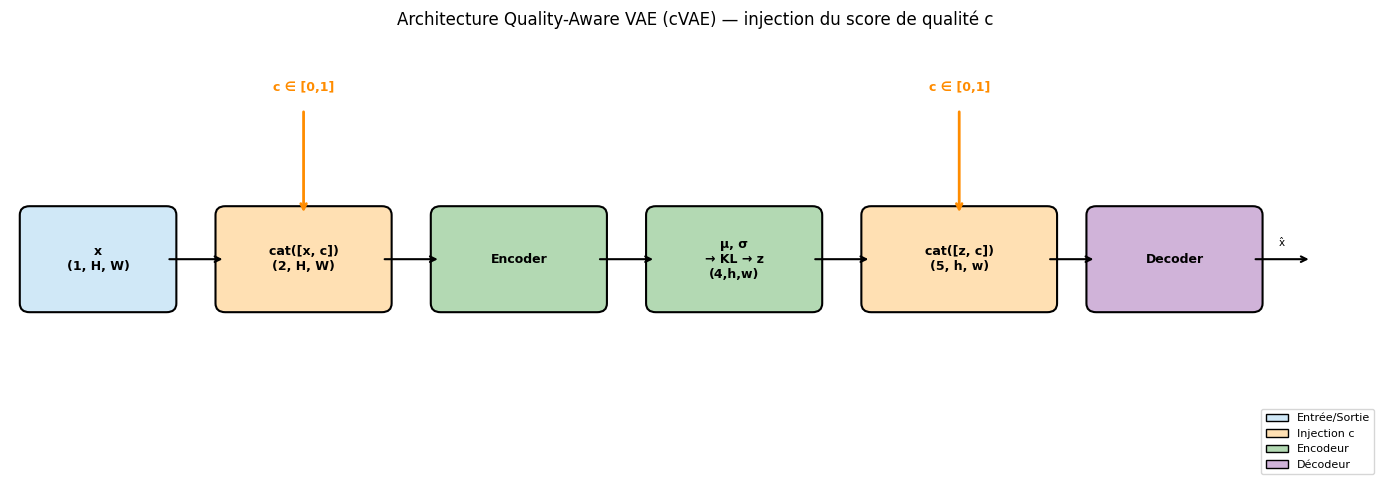

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

def box(ax, x, y, w, h, label, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", wrap=True)

def arrow(ax, x1, y, x2, label="", color="black"):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    if label:
        ax.text((x1+x2)/2, y + 0.15, label, ha="center", fontsize=7.5, color=color)

# Blocs
box(ax, 0.2, 2.0, 1.4, 1.0, "x\n(1, H, W)",          "#d0e8f7")
box(ax, 2.2, 2.0, 1.6, 1.0, "cat([x, c])\n(2, H, W)",  "#ffe0b3")
box(ax, 4.4, 2.0, 1.6, 1.0, "Encoder",                 "#b3d9b3")
box(ax, 6.6, 2.0, 1.6, 1.0, "μ, σ\n→ KL → z\n(4,h,w)","#b3d9b3")
box(ax, 8.8, 2.0, 1.8, 1.0, "cat([z, c])\n(5, h, w)",  "#ffe0b3")
box(ax, 11.1, 2.0, 1.6, 1.0, "Decoder",                "#d0b3d9")

# Flèches horizontales
arrow(ax, 1.6, 2.5, 2.2,  label="")
arrow(ax, 3.8, 2.5, 4.4,  label="")
arrow(ax, 6.0, 2.5, 6.6,  label="")
arrow(ax, 8.2, 2.5, 8.8,  label="")
arrow(ax, 10.6, 2.5, 11.1, label="")
arrow(ax, 12.7, 2.5, 13.3, label="x̂")

# Flèche c → encodeur
ax.annotate("", xy=(3.0, 3.0), xytext=(3.0, 4.2),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))
ax.text(3.0, 4.4, "c ∈ [0,1]", ha="center", fontsize=9, color="darkorange", fontweight="bold")

# Flèche c → décodeur
ax.annotate("", xy=(9.7, 3.0), xytext=(9.7, 4.2),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))
ax.text(9.7, 4.4, "c ∈ [0,1]", ha="center", fontsize=9, color="darkorange", fontweight="bold")

# Légende — handles passés directement sans add_patch (incompatible matplotlib >= 3.9)
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", label=label)
    for color, label in [
        ("#d0e8f7", "Entrée/Sortie"),
        ("#ffe0b3", "Injection c"),
        ("#b3d9b3", "Encodeur"),
        ("#d0b3d9", "Décodeur"),
    ]
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

ax.set_title("Architecture Quality-Aware VAE (cVAE) — injection du score de qualité c",
             fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_architecture_cvae.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Visualisation du mécanisme de conditionnement

### 7a. Reconstruction à différents c sur la même image

> **Note :** À l'initialisation, les poids du canal conditionnel sont zéro, donc c n'a pas encore d'effet visible.  
> Après l'entraînement (section 8), le réseau apprend à différencier les scores.

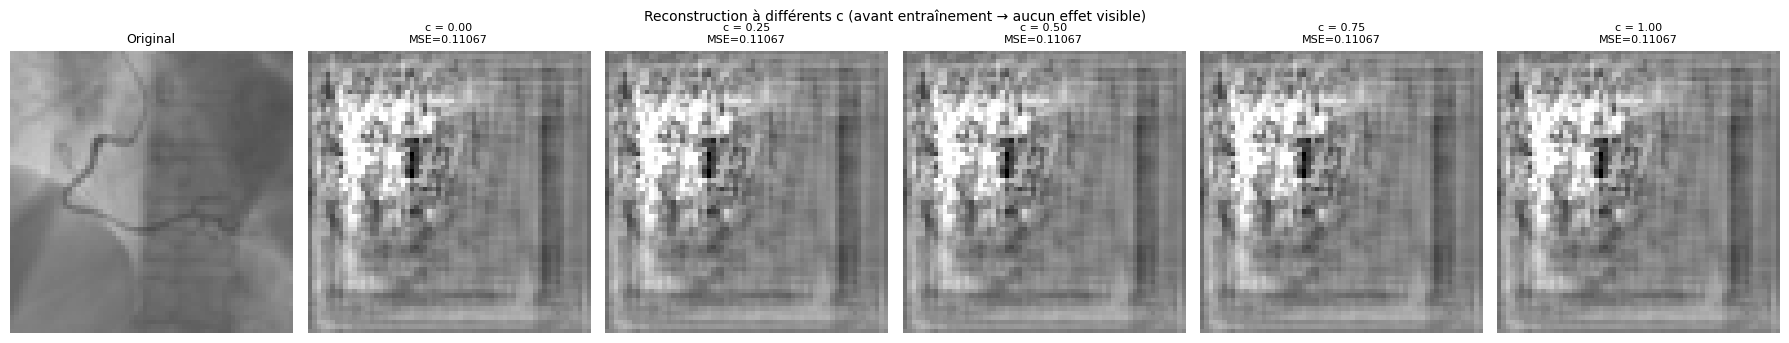

→ Les MSE sont identiques : le réseau n'a pas encore appris à utiliser c.


In [23]:
cvae.eval()
x_single = imgs_demo[:1].to(DEVICE)  # une seule image

c_values = [0.0, 0.25, 0.5, 0.75, 1.0]
recs = []
with torch.no_grad():
    for c_val in c_values:
        c_t = torch.tensor([c_val], dtype=torch.float32, device=DEVICE)
        rec, _, _ = cvae(x_single, c_t, sample_posterior=False)
        recs.append(rec.squeeze().cpu().numpy())

fig, axes = plt.subplots(1, len(c_values) + 1, figsize=(3 * (len(c_values) + 1), 3.5))

orig = x_single.squeeze().cpu().numpy()
axes[0].imshow((orig + 1) / 2, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for i, (c_val, rec) in enumerate(zip(c_values, recs)):
    axes[i + 1].imshow((rec + 1) / 2, cmap="gray", vmin=0, vmax=1)
    mse = float(np.mean((orig - rec) ** 2))
    axes[i + 1].set_title(f"c = {c_val:.2f}\nMSE={mse:.5f}", fontsize=8)
    axes[i + 1].axis("off")

fig.suptitle("Reconstruction à différents c (avant entraînement → aucun effet visible)",
             fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_conditioning_before_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Les MSE sont identiques : le réseau n'a pas encore appris à utiliser c.")

## 8. Boucle d'entraînement de démonstration

Loss utilisée : ELBO simplifié (MSE + KL) pour démontrer la convergence.  
Pour un entraînement complet, utiliser le `Phase1Trainer` adapté avec discriminateur et LPIPS.

In [24]:
def elbo_loss(
    x: torch.Tensor,
    rec: torch.Tensor,
    posterior: DiagonalGaussianDistribution,
    kl_weight: float = KL_WEIGHT,
):
    rec_loss = F.mse_loss(rec, x)
    kl_loss  = posterior.kl().mean()
    loss     = rec_loss + kl_weight * kl_loss
    return loss, {"rec": rec_loss.item(), "kl": kl_loss.item(), "total": loss.item()}


print("Loss ELBO définie.")

Loss ELBO définie.


In [25]:
optimizer = torch.optim.AdamW(cvae.parameters(), lr=LR, weight_decay=0.0)
cvae.train()

history = {"total": [], "rec": [], "kl": []}
step    = 0
loader_iter = iter(loader)

pbar = tqdm(total=N_WARMUP_STEPS, desc="Warm-up")

while step < N_WARMUP_STEPS:
    try:
        x_batch, c_batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        x_batch, c_batch = next(loader_iter)

    x_batch = x_batch.to(DEVICE)
    c_batch = c_batch.to(DEVICE)

    rec_batch, post_batch, _ = cvae(x_batch, c_batch, sample_posterior=True)
    loss, logs = elbo_loss(x_batch, rec_batch, post_batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(cvae.parameters(), 1.0)
    optimizer.step()

    for k in history:
        history[k].append(logs[k])

    step += 1
    pbar.set_postfix({"loss": f"{logs['total']:.5f}", "rec": f"{logs['rec']:.5f}"})
    pbar.update(1)

pbar.close()
print(f"\nEntraînement terminé — loss finale : {history['total'][-1]:.6f}")

Warm-up: 100%|██████████| 50/50 [02:12<00:00,  2.65s/it, loss=0.04572, rec=0.04524]


Entraînement terminé — loss finale : 0.045717


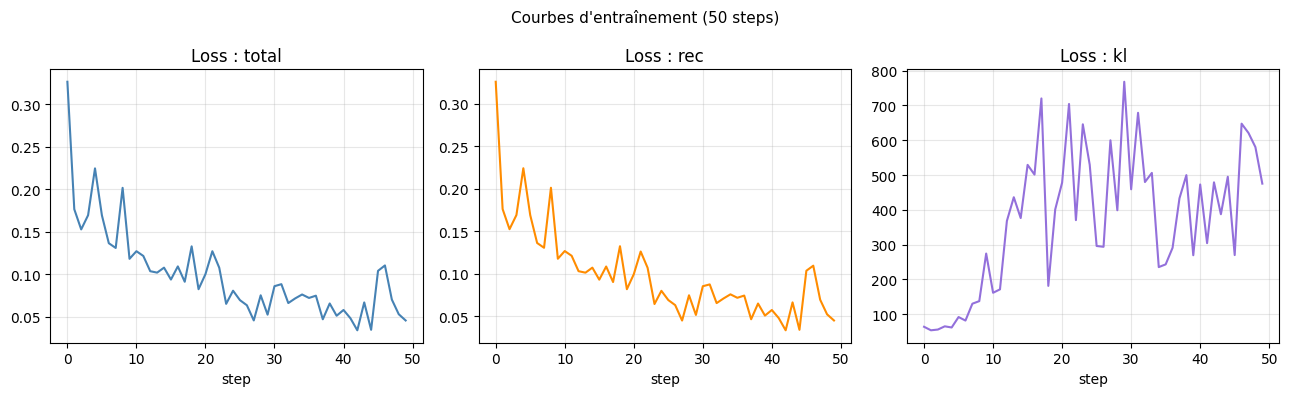

In [26]:
# Courbe de loss
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, key, color in zip(axes, ["total", "rec", "kl"],
                           ["steelblue", "darkorange", "mediumpurple"]):
    ax.plot(history[key], color=color, lw=1.5)
    ax.set_title(f"Loss : {key}")
    ax.set_xlabel("step")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Courbes d'entraînement ({N_WARMUP_STEPS} steps)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_training_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. Visualisation après entraînement : le score c commence à avoir un effet

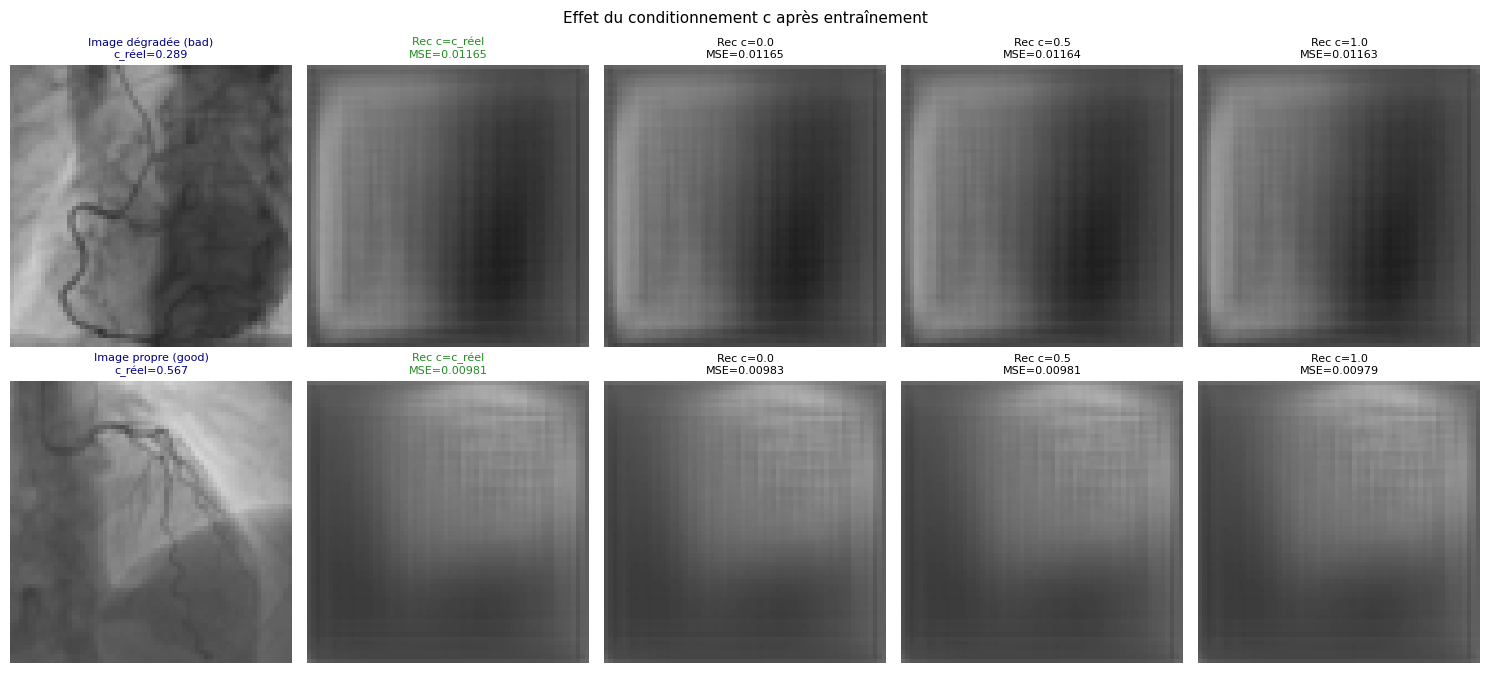

In [27]:
cvae.eval()

# Prendre une image "bad" et une image "good"
df_bad  = df_labels[df_labels["quality_label"] == "bad"].head(1)
df_good = df_labels[df_labels["quality_label"] == "good"].head(1)

def load_and_prepare(row, img_size=DDCONFIG["resolution"]):
    img = Image.open(row["path"].values[0]).convert("L")
    img = img.resize((img_size, img_size), Image.Resampling.BILINEAR)
    t   = torch.from_numpy(np.asarray(img, np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    return (t * 2.0 - 1.0).to(DEVICE)

imgs_pair  = [load_and_prepare(df_bad),  load_and_prepare(df_good)]
labels_pair= ["Image dégradée (bad)",    "Image propre (good)"]
c_real_pair= [float(df_bad["quality_score"].values[0]),
              float(df_good["quality_score"].values[0])]

c_test_vals = [0.0, 0.5, 1.0]

fig, axes = plt.subplots(2, len(c_test_vals) + 2, figsize=(3 * (len(c_test_vals) + 2), 7))

for row, (x_img, lbl, c_real) in enumerate(zip(imgs_pair, labels_pair, c_real_pair)):
    # Colonne 0 : original
    orig_np = ((x_img.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
    axes[row, 0].imshow(orig_np, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{lbl}\nc_réel={c_real:.3f}", fontsize=8, color="navy")
    axes[row, 0].axis("off")

    # Colonne 1 : reconstruction avec c réel
    with torch.no_grad():
        c_t   = torch.tensor([c_real], device=DEVICE)
        rec_r, _, _ = cvae(x_img, c_t, sample_posterior=False)
    rec_np = ((rec_r.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
    axes[row, 1].imshow(rec_np, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Rec c=c_réel\nMSE={np.mean((orig_np - rec_np)**2):.5f}",
                            fontsize=8, color="forestgreen")
    axes[row, 1].axis("off")

    # Colonnes 2+ : c imposé
    for col, c_val in enumerate(c_test_vals):
        with torch.no_grad():
            c_t2  = torch.tensor([c_val], device=DEVICE)
            rec_t, _, _ = cvae(x_img, c_t2, sample_posterior=False)
        rec_np2 = ((rec_t.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
        axes[row, col + 2].imshow(rec_np2, cmap="gray", vmin=0, vmax=1)
        axes[row, col + 2].set_title(
            f"Rec c={c_val:.1f}\nMSE={np.mean((orig_np - rec_np2)**2):.5f}", fontsize=8
        )
        axes[row, col + 2].axis("off")

fig.suptitle("Effet du conditionnement c après entraînement", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_conditioning_after_training.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Sauvegarde du checkpoint

Le checkpoint contient le modèle conditionné ET la config nécessaire pour le reconstruire dans le Notebook 5.

In [28]:
checkpoint = {
    "model_state_dict":  cvae.state_dict(),
    "optimizer_state":   optimizer.state_dict(),
    "ddconfig":          DDCONFIG,
    "embed_dim":         EMBED_DIM,
    "training_steps":    N_WARMUP_STEPS,
    "history":           history,
    "labels_csv":        str(LABELS_CSV),
    "param_count":       cvae.param_count(),
}

torch.save(checkpoint, CVAE_CKPT_OUT)
print(f"Checkpoint sauvegardé → {CVAE_CKPT_OUT}")
print(f"Taille fichier : {CVAE_CKPT_OUT.stat().st_size / 1e6:.1f} MB")

Checkpoint sauvegardé → C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae\code_tests\outputs\quality_aware_vae.pt
Taille fichier : 664.3 MB


In [29]:
# Vérification du rechargement
def load_quality_aware_vae(ckpt_path: Path) -> QualityAwareAutoencoderKL:
    ckpt    = torch.load(ckpt_path, map_location="cpu")
    base_ae = AutoencoderKL2D(
        ddconfig         = ckpt["ddconfig"],
        embed_dim        = ckpt["embed_dim"],
        apply_channel_ds = True,
    )
    model = QualityAwareAutoencoderKL(base_ae)
    model.load_state_dict(ckpt["model_state_dict"])
    return model

cvae_reloaded = load_quality_aware_vae(CVAE_CKPT_OUT)
print("Rechargement OK :", cvae_reloaded.param_count())

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 512 in_channels
Rechargement OK : {'total': 55364605, 'new_params': 5760, 'ratio_%': 0.010403758863627764}


## Résumé du Notebook 4

| Composant | Modification | Détail |
|---|---|---|
| `encoder.conv_in` | `Conv2d(1→2, 128, 3)` | +1 canal pour $c$ spatial |
| `decoder.conv_in` | `Conv2d(4→5, 512, 3)` | +1 canal pour $c$ spatial |
| Poids existants | **Inchangés** | Copie exacte des poids pre-trained |
| Nouveaux filtres | Zero-init | Pas d'effet au démarrage |
| `QualityAwareArcadeDataset` | Retourne `(img, c)` | c lu depuis `labels_quality.csv` |
| Paramètres supplémentaires | `< 0.01%` du total | Overhead négligeable |

**Prochain notebook :** `05_Evaluation_of_Robustness.ipynb` —  
Comparer MedVAE baseline vs Quality-Aware sur les images dégradées : MSE, SSIM, reconstruction visuelle.